# EDA for carbreakdown data

In deze notebook gaan we de dataset in in train_CarBreakDown onderzoeken. Eerst starten we met een algemeen zicht op de data set via een describe. Dit world gevolgd door null waarde weg te halen want deze zullen de eind resultaten het meest beïnvloeden. Dan kijken we de verdelingen van de data per kollom om te zien als er dingen opvallen. Als laatst kijken we nog voor enige andere eigenaardigheden.

## Obtain data in variabel

Eerst starten we met het inlezen van de data. Hierop voeren we direct een describe uit om een snel overzicht van de data te verkrijgen.

In [114]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# read csv file
df = pd.read_csv('../csv/train/train_CarBreakDown.csv')
print(f"Null value overview:\n{df.isnull().sum()}\n")
print(f"Total nulls in dataset: {df.isnull().sum().sum()}")
print(f"Gemiddelde nulls in dataset: {round(df.isnull().sum().mean())}")
print(f"Totaal aantal records {len(df)}")
df.describe(include='all')


# initial suspicions:
# all collumns are missing values except id (logical) and breakdown _next_30_days which is our goal to calculate
# There negative values in mileage_km, engine_hours and cleanliness_score which should not be possible
# oil_quality is a percentage but max is 102...
# same with cleanliness_score
# maybe driver_satisfaction to

Null value overview:
id                            0
vehicle_brand                21
vehicle_age_years            16
mileage_km                   17
engine_hours                 15
last_service_km_ago          10
oil_quality_pct              36
avg_trip_length_km           12
weather_exposure             13
fuel_type                    14
cleanliness_score            55
driver_satisfaction_score    13
tyre_type                    17
breakdown_next_30_days        0
dtype: int64

Total nulls in dataset: 239
Gemiddelde nulls in dataset: 17
Totaal aantal records 1050


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
count,1050.000000,1029,1034.000000,1.033000e+03,1035.000000,1040.000000,1014.000000,1038.000000,1037,1036,995.000000,1037.000000,1033,1050.000000
unique,NaN,9,NaN,NaN,NaN,NaN,NaN,NaN,4,5,NaN,NaN,4,NaN
top,NaN,Ford,NaN,NaN,NaN,NaN,NaN,NaN,medium,petrol,NaN,NaN,summer,NaN
freq,NaN,194,NaN,NaN,NaN,NaN,NaN,NaN,428,435,NaN,NaN,386,NaN
mean,742.984762,NaN,9.399420,3.639119e+06,4368.929467,10681.075986,60.682779,38.861387,NaN,NaN,69.393768,6.972183,NaN,0.167619
std,430.089010,NaN,5.752228,2.585818e+07,2214.510223,9341.969609,20.298624,47.968702,NaN,NaN,15.570872,1.478278,NaN,0.373706
min,0.000000,NaN,0.000000,-1.829042e+02,-50.000000,10.869020,0.000000,1.011100,NaN,NaN,-13.171570,2.504369,NaN,0.000000
25%,372.250000,NaN,5.000000,8.338616e+04,2773.353090,3374.773323,47.377582,8.187057,NaN,NaN,58.902723,6.001099,NaN,0.000000
50%,740.500000,NaN,9.000000,1.202357e+05,3967.125562,8085.318122,60.528422,16.788852,NaN,NaN,69.504547,6.928004,NaN,0.000000
75%,1109.250000,NaN,14.000000,1.674871e+05,5432.498224,14455.318280,74.654436,44.308719,NaN,NaN,79.597898,8.022503,NaN,0.000000


Uit de bovenstaande analyse is te zien dat 239 waarden over alle kollomen (1050) niet ingevuld is. Dit betekent dat we maximum 23% van de data verliezen, er van uit gaand dat elke null in een verschillend record voorkomt.

We kunnen hier op twee manier mee omgaan, amputatie of imputatie.

**Amputatie**: Het verwijderen van de rij of kollomen die null waarde bevatten om enkel over te blijven met ingevulde records. Dit is ten koste van de grote van de data set.

**Imputatie**: Het vervangen van de data, vaak door het gemiddelde of median om de data volledig te maken. Dit kan enkel als de rest van de gegevens ok zijn en kan de gegevens veralgemene.

 Zelfs als het niet exact 23%, 15% (893 resterend in dat geval) zou ook all veel impact hebben op de resultaten omdat de data set redelijk klein is. Het is dus het beste om zoveel mogelijk kollomen te imputeren. Dit gaat niet alteid handig zijn zoals bij vehicle brand, hier zal dan amputatie gebruikt worden.

## Per kollom null waarde behandeling

Nu gaan we per kollom af om te kijken wat er aangepast kan worden zoals het droppen/imputeren van null waarde. Er zijn twee soorten kollom in de dataset numerique en categorische. 

Bij numerique kollomen wordt er gekeken naar de verdeling van de waarde via een boxplot om te zien als er onwaarscheinlijke uitschieters zijn.

Bij categorische waarde kan dit natuurlijk niet en wordt er via een barchart gekeken hoe de verdeling is tussen categorieën. All deze kollomen hebben een "other" kollom en afhankelijk van de grote hier van kunnen de records hiervan ook gedropt worden omdat deze data niet specifiek is (het is well beter dan null). Dit maakt het bewaren van kollom waar het mogelijk is nog beter want dan kunnen other kollomen makkelijker gedropt worden.

### vehicle_brand

Kollom null waardes: 21
vehicle_brand
Ford          194
Toyota        193
Volkswagen    143
BMW           125
Hyundai       101
Renault        97
Volvo          93
Kia            69
other          14
Name: count, dtype: int64


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,494744.972722,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
2,1304,Hyundai,1.0,188558.432414,6678.958321,11726.320455,25.491428,41.692205,medium,hybrid,47.223966,5.842726,winter,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
5,606,Renault,1.0,209439.442769,7156.897259,3527.010815,52.147399,1.458703,high,hybrid,57.117174,7.676373,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,NaN,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


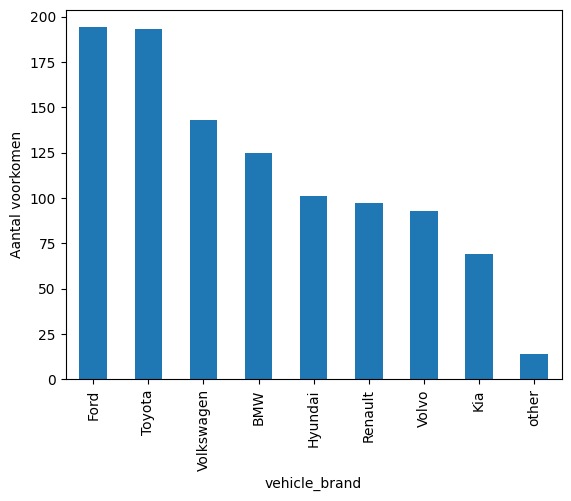

In [115]:
vehicle_brand = df['vehicle_brand']
print(f"Kollom null waardes: {vehicle_brand.isnull().sum()}")

print(df.vehicle_brand.value_counts())
df['vehicle_brand'].value_counts().plot(kind='bar',ylabel='Aantal voorkomen')


df.dropna(subset='vehicle_brand', inplace=True) # subset is gebruikt om enkel 1 kollom de records te droppen
df


Vehicle_brand is een categorische kollom, hierdoor wordt er zeker geamputeerd. Het heeft een boven gemiddeld aantal null waarde maar de gemiddelde category nemen zou niet een goede oplossing zijn want dan wordt deze over gerepresenteerd.

 Interresant om te zien is dat de verdeling van merken niet even ligt en sommige veel meer voorkomen.

### vehicle_age

Kollom snel overzicht: 

Kollom null waardes: 16
Kollom gemiddelde: 9.385982230997039
Kollom median: 9.0

Algemene Data Na aanpassing


np.float64(nan)

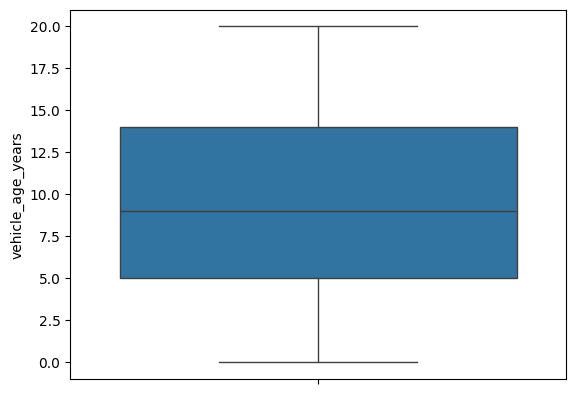

In [116]:
vehicle_age = df['vehicle_age_years']

print("Kollom snel overzicht: \n")
print(f"Kollom null waardes: {vehicle_age.isnull().sum()}")
print(f"Kollom gemiddelde: {vehicle_age.mean()}")
print(f"Kollom median: {vehicle_age.median()}")

sns.boxplot(data=df, y='vehicle_age_years')

df.fillna({'vehicle_age_years':vehicle_age.mean()},inplace=True) # use dictonairy to specify which collum to change

print("\nAlgemene Data Na aanpassing")
vehicle_age.describe()
vehicle_age[92]